# From text to tensors: tokenization & embeddings

The previous notebooks worked with neat numerical inputs: floats for curve fitting, pixel grids for MNIST. Real-world language data isn't like that — it's strings of characters, words, emojis. Before a neural network can do anything with text, we need to **turn it into numbers**.

That conversion has two stages, and they are surprisingly deep topics on their own:

1. **Tokenization** — chop text into discrete pieces ("tokens") and assign each token an integer id. This is what `data/shakespeare_char/prepare.py` does in this repo; it's also what `tiktoken` does for GPT models, what `sentencepiece` does for Llama, and so on.

2. **Embedding** — turn those integer ids into dense, learned vectors that the rest of the network can manipulate with linear algebra. `nn.Embedding` is just a lookup table of learnable weights.

In this notebook we'll work through both stages on Karpathy's Tiny Shakespeare, and along the way build the intuition needed to read tokenizer tables for GPT-2, GPT-4o, Llama, Gemini, and friends.

In **notebook 6** we then take the tokenized data from here and use it to train a character-level RNN.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import datetime as dt
import urllib.request

import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
import torch
import torch.nn as nn
from torch.utils.tensorboard import SummaryWriter
from tqdm.notebook import tqdm

pio.renderers.default = "notebook"

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(1337)
print(f"PyTorch: {torch.__version__}")
print(f"Device:  {device}")

PyTorch: 2.12.0+cu130
Device:  cuda


## The data

We use **Tiny Shakespeare** — a 1.1 MB concatenation of several plays. It's the same file `data/shakespeare_char/prepare.py` downloads, but since we already have the URL, we'll fetch it directly here for self-containment.

For our purposes the "vocabulary" is just the set of distinct characters that appear in the file (letters, punctuation, newline, …). Each character becomes an integer between 0 and `vocab_size − 1`.

This is **character-level** modeling — the dumbest possible tokenization, but it works surprisingly well at small scale and keeps the demo dependency-free (no BPE library needed).

In [6]:
data_path = "data/shakespeare_char/input.txt"
if not os.path.exists(data_path):
    os.makedirs(os.path.dirname(data_path), exist_ok=True)
    url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
    print(f"Downloading {url} ...")
    urllib.request.urlretrieve(url, data_path)

with open(data_path, "r") as f:
    text = f.read()

print(f"Corpus length: {len(text):,} characters")
print()
print("Sample:")
print("-" * 60)
print(text[:300])
print("-" * 60)

Corpus length: 1,115,394 characters

Sample:
------------------------------------------------------------
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us
------------------------------------------------------------


## Tokenization

In order to work with (text-)sequences, we need to "tokenize" them
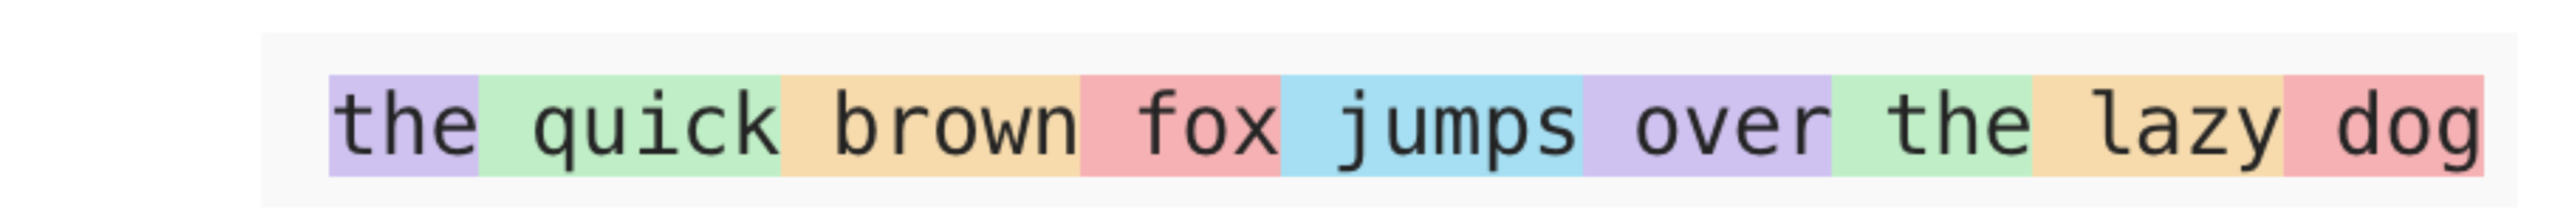

Tokenization is a whole field of research on its own.

### Three strategies, in increasing cleverness

| Strategy | What's a token? | Vocab size | Example: `"Tokenization"` |
| --- | --- | --- | --- |
| **Character** | a single character | tens (here: 65) | `T  o  k  e  n  i  z  a  t  i  o  n` (12 tokens) |
| **Word** | a whitespace-separated word | hundreds of thousands (one per word form) | `Tokenization` (1 token, **if** the word was ever seen) |
| **Subword (BPE / WordPiece / SentencePiece)** | frequent character chunks learned from data | tens of thousands | `Token` + `ization` (2 tokens) |

- **Character** is the simplest. Tiny vocab, no out-of-vocabulary problem (anything is representable), but sequences are very long — the model has to learn spelling *and* grammar simultaneously, and 1000-character sentences make context-length budgets brutal.
- **Word** is what classical NLP did. Tokens carry a lot of meaning each, but the vocab explodes (every plural, every typo, every proper noun is its own entry) and any word the tokenizer hasn't seen becomes `<UNK>` — game over.
- **Subword** is the modern sweet spot. Common words are one token (`the`, `and`, `Token`), rare words decompose into pieces (`Tokeniz` + `ation`), and *anything* — including made-up words, emoji, Klingon — is representable as a sequence of bytes. Every state-of-the-art LLM uses some variant of this.

### What real models actually use

A snapshot of popular tokenizers — algorithm, vocab size, and roughly how many characters of English each token covers on average. The last column is what really matters: it sets the *cost per page of text*, both in compute and (for API models) in dollars.

| Model / family | Tokenizer | Algorithm | Vocab size | ≈ chars / token (English)¹ |
| --- | --- | --- | ---: | ---: |
| `5_rnn.ipynb` (this notebook) | hand-rolled | character | **65** | 1.0 |
| BERT (2018) | `bert-base-uncased` | WordPiece | 30,522 | ~4.0 |
| GPT-2 / GPT-3 (2019–2020) | `gpt2` | byte-level BPE | 50,257 | ~4.0 |
| Llama 2 / Mistral 7B (2023) | sentencepiece | SentencePiece BPE | 32,000 | ~3.5 |
| GPT-3.5 / GPT-4 (2023) | `cl100k_base` | byte-level BPE | 100,277 | ~4.0 |
| Llama 3 (2024) | `tiktoken`-style | byte-level BPE | 128,256 | ~4.3 |
| DeepSeek-V3 (2024) | sentencepiece | byte-level BPE | 129,280 | ~4.5 |
| Qwen2 / 2.5 (2024) | sentencepiece | byte-level BPE | ~151,936 | ~4.5 |
| GPT-4o (2024) | `o200k_base` | byte-level BPE | 200,019 | ~4.5–5.0 |
| Gemini / PaLM 2 (2024) | sentencepiece | SentencePiece | ~256,128 | ~5.0 |

¹ Approximate, measured on plain English prose. Code, numbers, and non-English text give very different ratios — see notes below.

A few observations:

- The whole field migrated to **byte-level BPE / SentencePiece** because they handle arbitrary input bytes (no `<UNK>`) and learn an efficient packing from data.
- **Vocab sizes are growing**: 30k → 50k → 100k → 200k+. The trend is "more tokens, each carrying more meaning" — which trades a wider output softmax for a shorter sequence per word.
- The biggest jumps usually come from **multilingual coverage** and **code support**. GPT-4o's 200k vocab specifically buys far better compression on Chinese, Hindi, Arabic, and source code than GPT-3.5's 100k did.

### Why the choice matters — practical consequences

Tokenization isn't just plumbing. The strategy a model team picks shows up everywhere downstream:

- **Compute and context budget.** A transformer's attention cost is **quadratic in sequence length**. A model whose tokenizer compresses 4.5 chars/token instead of 3.5 sees a 1.3× shorter sequence for the same text — and ~1.7× less attention compute. Same reason a "1M-token context window" sounds huge in English but feels much smaller in some other languages.

- **Multilingual fairness.** English-trained BPE compresses English well; languages it has barely seen get one-byte-at-a-time encoding. Burmese, Sinhalese, and Tibetan text can take **5–10× more tokens** than the equivalent English content in older tokenizers. Same input, same context, but non-English users pay more (API cost) and lose more (effective context). Newer tokenizers (`o200k_base`, Gemini's 256k vocab) explicitly fix this by allocating more vocab slots to non-Latin scripts.

- **Numbers and arithmetic.** GPT-3's tokenizer would split `1234` into `123` + `4`, or `12` + `34`, depending on frequency — basically nondeterministically from the model's perspective. That's part of why early LLMs were so bad at multi-digit arithmetic. Newer tokenizers (`cl100k_base`, `o200k_base`, Llama 3) deliberately tokenize digits **one at a time**, giving the model a uniform representation it can actually reason over.

- **Code.** Python's significant whitespace destroys naïve tokenizers — `    ` (four spaces) was 4 tokens in older BPEs, blowing up Python files. Modern tokenizers learn merges for `\n    `, `\n        `, etc., shrinking Python source by 30–50% and making code models economically viable.

- **Capability holes are tokenizer holes.** "How many R's in 'strawberry'?" fails because the model never sees individual letters — it sees `straw` + `berry` as two opaque ids. The same logic explains a lot of LLM weirdness around spelling, reversing, anagrams, and word counts. The model isn't bad at reading; it literally **can't see the characters**.

- **Vocab size ↔ embedding & output cost.** Every extra token in the vocab adds a row to the embedding table (input) and a row to the unembedding matrix (output softmax). For a model with hidden size `d`, the embedding + LM-head together cost `2 · vocab_size · d` parameters. A 256k vocab at `d=4096` is 2 GB in fp32 just for those two layers, which is why most open-source LLMs sit around 32k–128k rather than going bigger.

The TL;DR: **tokenization is the lossy interface between the messy real world and the model's clean integer indices**, and every quirk of that interface propagates into model behavior. The char-level encoding we use in this notebook is the absolute simplest case — tiny vocab, no learned merges, and the model carries the full burden of learning what a word is.

### Aside: **glitch tokens** — when a vocab entry was never actually trained

Tokenizers are learned **separately** from the model, on a different (often larger) corpus. A side effect: the vocab can contain entries that the *language model itself* barely ever saw during training. With essentially no gradient signal pointing to those rows of the embedding table, the embedding vector stays close to its random initialization. The model has no idea what the token means.

When you then prompt the model with one of these "glitch tokens", it produces **unhinged output**: hallucinated translations, refusals, gibberish, repetition loops, or sometimes a totally unrelated string that the random init happens to be near.

The most famous example is the GPT-3 token ` SolidGoldMagikarp` (a Reddit username that got into the BPE training corpus but not the LM training corpus). Asking GPT-3 to repeat it would cause it to say "distribute" or "disperse" or hallucinate confidently in unrelated directions. Every major model family has its own collection — Llama 2 included.

> 🖥️ **Live demo:** switching to a terminal running Llama 2 to trigger one of its known glitch tokens. Watch what happens when you feed the model a string it technically *can* tokenize but has no semantic embedding for.

In [8]:
# Build the character vocab
chars = sorted(set(text))
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}
print(stoi)

def encode(s):  return [stoi[c] for c in s]
def decode(xs): return "".join(itos[int(i)] for i in xs)



{'\n': 0, ' ': 1, '!': 2, '$': 3, '&': 4, "'": 5, ',': 6, '-': 7, '.': 8, '3': 9, ':': 10, ';': 11, '?': 12, 'A': 13, 'B': 14, 'C': 15, 'D': 16, 'E': 17, 'F': 18, 'G': 19, 'H': 20, 'I': 21, 'J': 22, 'K': 23, 'L': 24, 'M': 25, 'N': 26, 'O': 27, 'P': 28, 'Q': 29, 'R': 30, 'S': 31, 'T': 32, 'U': 33, 'V': 34, 'W': 35, 'X': 36, 'Y': 37, 'Z': 38, 'a': 39, 'b': 40, 'c': 41, 'd': 42, 'e': 43, 'f': 44, 'g': 45, 'h': 46, 'i': 47, 'j': 48, 'k': 49, 'l': 50, 'm': 51, 'n': 52, 'o': 53, 'p': 54, 'q': 55, 'r': 56, 's': 57, 't': 58, 'u': 59, 'v': 60, 'w': 61, 'x': 62, 'y': 63, 'z': 64}


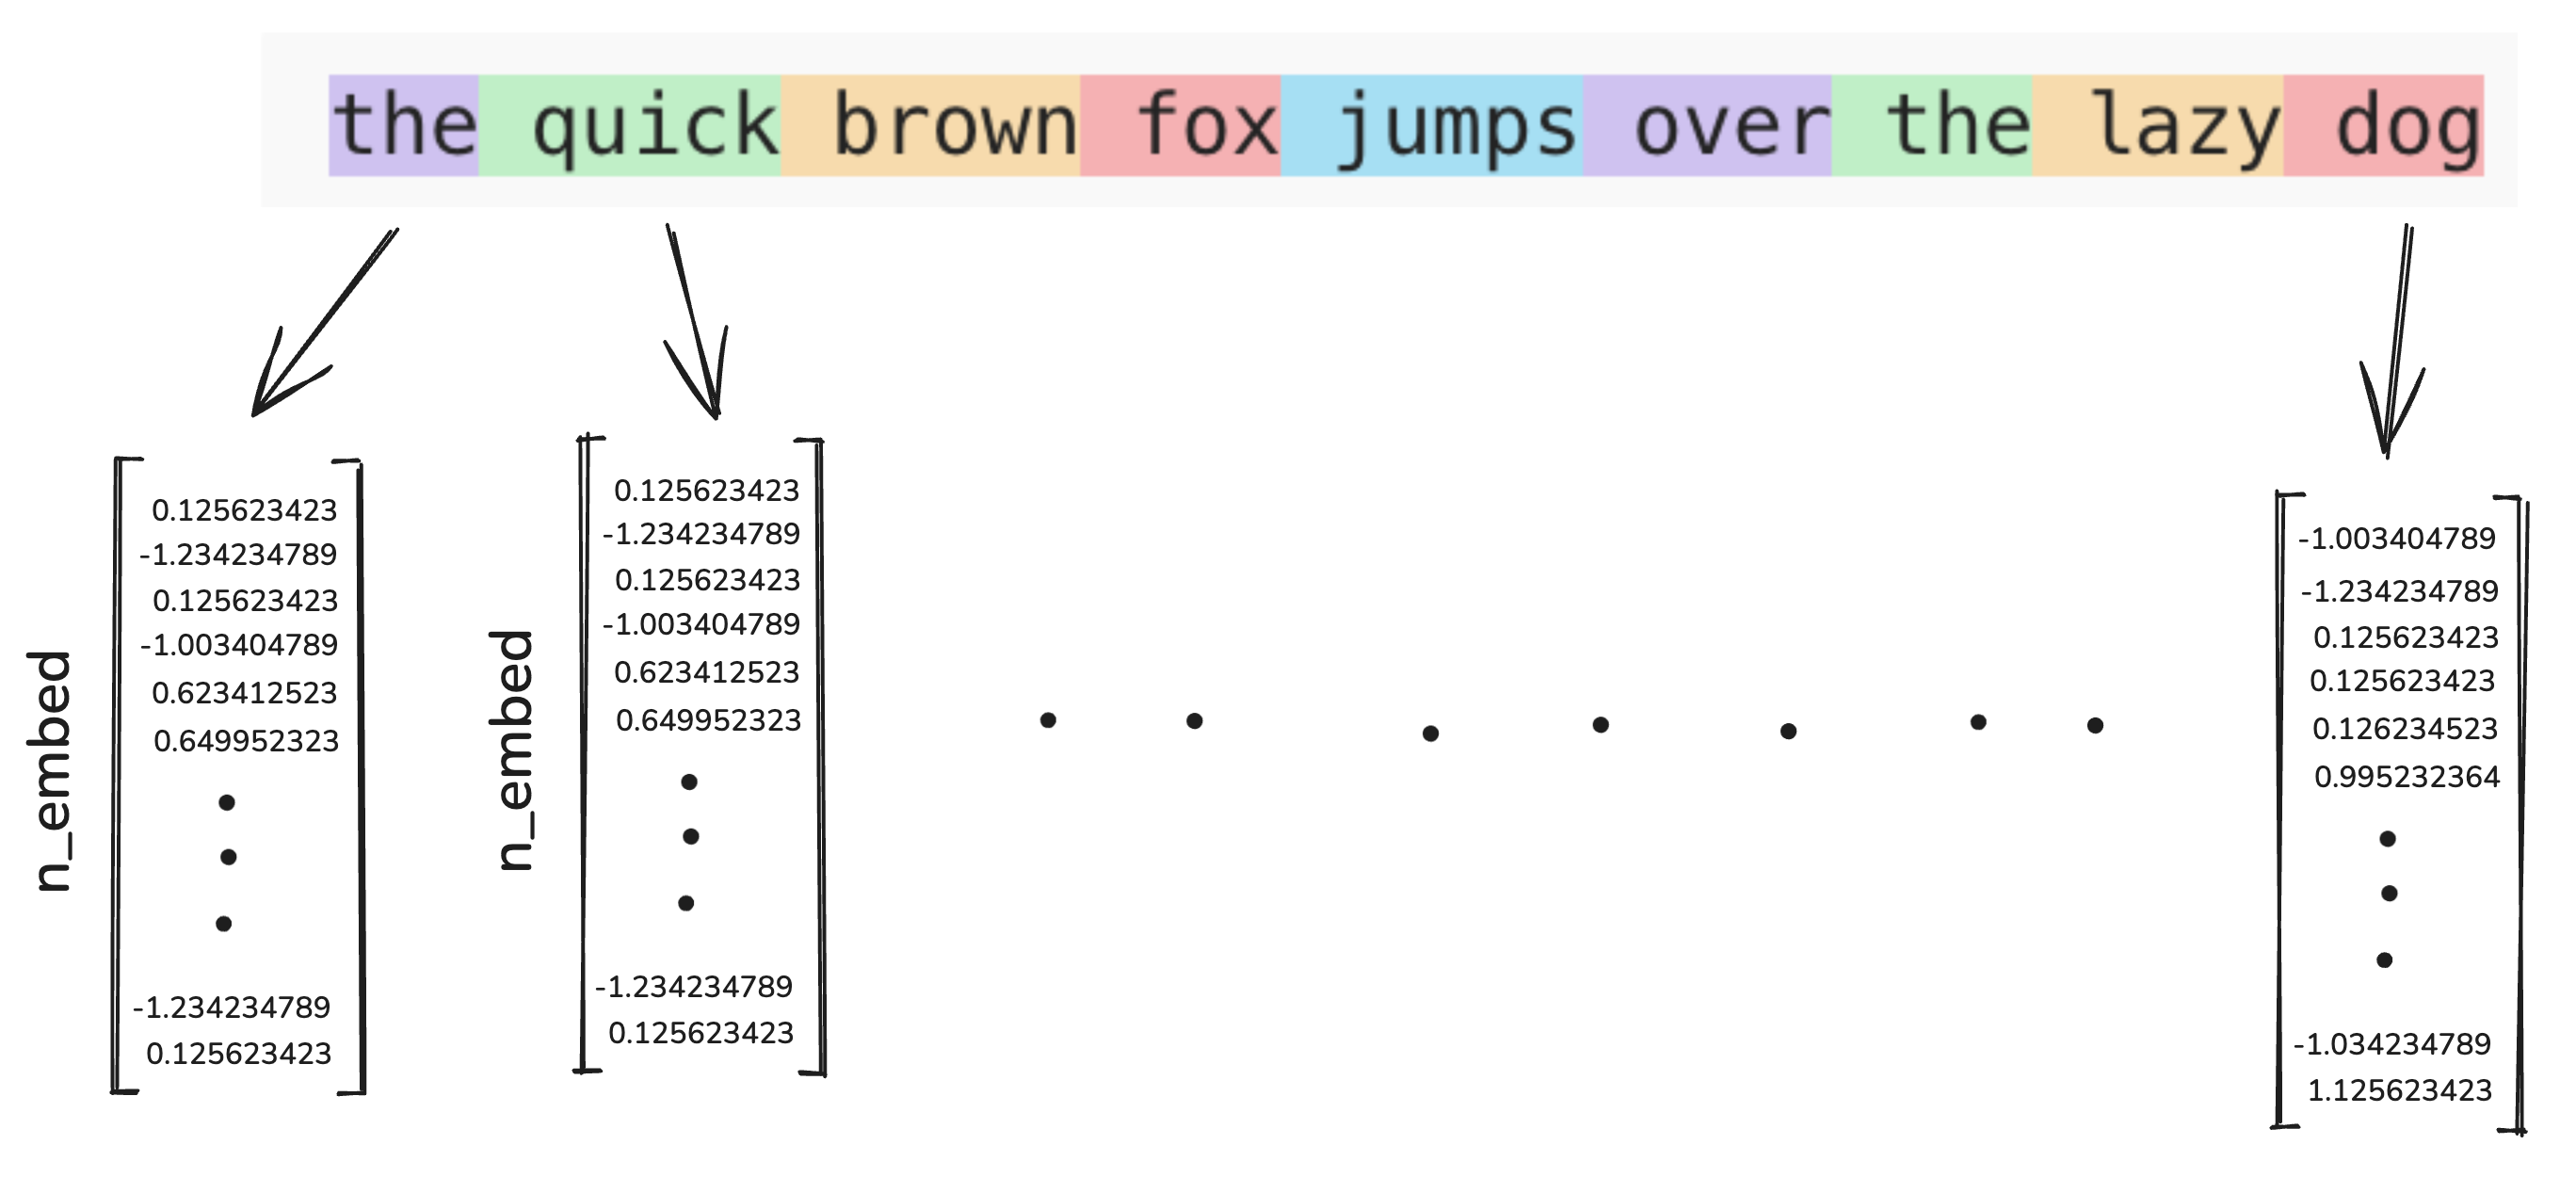

In [ ]:
print(f"\nVocab size: {vocab_size}")
print(f"Vocab:     {''.join(chars)!r}")

# Tokenize the whole corpus + train/val split
data = torch.tensor(encode(text), dtype=torch.long)
n_train = int(0.9 * len(data))
train_data, val_data = data[:n_train], data[n_train:]
print(f"\nTrain: {len(train_data):,} tokens, Val: {len(val_data):,} tokens")

## Wait — where do those embedding vectors come from?

You've tokenized the text and now every character is an integer between 0 and 64. The next line in our model will be:

```python
self.embed = nn.Embedding(vocab_size, hidden_size)
```

which somehow conjures up a learned dense vector for each of those 65 characters. The transition from "I have integers" to "I have meaningful 256-dimensional vectors" feels like sleight of hand. Let's unpack it.

### `nn.Embedding(V, H)` is **just a `V × H` matrix**

Under the hood, `nn.Embedding(65, 256)` allocates a single learnable parameter: a matrix `W` of shape `(65, 256)`. That's it. Initially the values are drawn from $\mathcal{N}(0, 1)$ — completely random.

When you call `self.embed(7)`, the layer **returns row 7** of that matrix — a single vector of length 256. Calling it on a batch of integers returns the corresponding stack of rows.

### Why is this called a "linear layer"?

Mathematically, "look up row 7 of $W$" is identical to "multiply $W$ by a one-hot vector with a 1 in position 7":

$$
\underbrace{[0,0,0,0,0,0,0,1,0,\ldots,0]}_{1 \times V} \;\cdot\; \underbrace{W}_{V \times H} \;=\; \text{row 7 of } W
$$

But materializing a 65-dim one-hot vector and doing a full matrix multiply is wasteful — 64 of the 65 multiplications are by zero. `nn.Embedding` is the optimized version that skips the one-hot and indexes into the rows directly. Same math, faster, and gradients still work because…

### …it learns through plain gradient descent

The embedding matrix is registered as an `nn.Parameter`, so PyTorch tracks gradients through it like any other weight matrix:

1. **Forward**: row 7 of $W$ flows into the rest of the network. A loss gets computed at the end.
2. **Backward**: autograd walks the chain rule back. When it reaches the embedding step, it has a gradient for the output vector, and it deposits that gradient onto **row 7** of $W$ (and *only* row 7 — none of the other rows were touched in this forward pass).
3. **Optimizer step**: row 7 is nudged in the direction that would have made the loss smaller.

After many batches, every row has drifted from its random starting point into a region of 256-dimensional space that's useful for the task — predicting the next character.

### What ends up encoded in the vectors?

The model isn't told what the integers "mean"; it discovers whatever structure helps it predict. For Shakespeare char-RNNs you'd typically find that after training:

- **Vowels** end up close to each other (they appear in similar contexts).
- **Capital letters** form a cluster (they share the "start of line / start of name" role).
- **Punctuation** sits in its own neighborhood, far from letters.
- Characters that almost never appear stay close to their random init (very little gradient signal to move them).

For *word*-level models the structure gets richer — the famous `king − man + woman ≈ queen` analogy works because word embeddings learn semantic regularities, not just syntactic ones.

### The output layer is the mirror image

At the *top* of the model, `self.W_hy = nn.Linear(hidden_size, vocab_size)` is another `(vocab_size × hidden_size)` matrix — it turns a hidden vector back into a score (logit) for each character. Some architectures explicitly **tie** these two matrices (`self.W_hy.weight = self.embed.weight`), saving parameters; nanoGPT does this optionally.

**TL;DR**: the embedding layer is just a normal weight matrix with a lookup-style forward pass. Nothing special happens at train time — backprop deposits gradients on the rows that were used, and an optimizer pushes those rows toward better values. The "meaning" of each vector is whatever the rest of the network has nudged it into being useful for.

In [13]:
# A tiny, concrete look at what nn.Embedding actually contains.

toy = nn.Embedding(num_embeddings=5, embedding_dim=3)
print("toy.weight is a learnable Parameter of shape:", tuple(toy.weight.shape))
print(f"requires_grad: {toy.weight.requires_grad}\n")
print("Initial (random) weight matrix:")
print(toy.weight.data, "\n")

# Look up token id 2 — that's literally row 2 of the matrix
print("toy(torch.tensor([2])) returns row 2 of the matrix:")
print(toy(torch.tensor([2])).detach(), "\n")

# Same result via one_hot @ W (slower, but proves they're equivalent)
one_hot = torch.zeros(1, 5); one_hot[0, 2] = 1.0
print("one_hot_at_position_2 @ toy.weight :")
print((one_hot @ toy.weight).detach())

toy.weight is a learnable Parameter of shape: (5, 3)
requires_grad: True

Initial (random) weight matrix:
tensor([[-0.0853, -1.1869, -0.9742],
        [ 0.9708,  0.0684, -1.3734],
        [ 0.1054, -0.0563,  0.4301],
        [ 0.2503,  1.5058,  0.0724],
        [-0.6659,  3.0324, -0.0939]]) 

toy(torch.tensor([2])) returns row 2 of the matrix:
tensor([[ 0.1054, -0.0563,  0.4301]]) 

one_hot_at_position_2 @ toy.weight :
tensor([[ 0.1054, -0.0563,  0.4301]])


## Wrapping up

We can now do the two things every text-based neural network needs:

- **Tokenize**: a deterministic function that turns a string into a sequence of integer ids (and back).
- **Embed**: a learnable `(vocab_size × hidden_size)` matrix that maps each integer id to a dense vector.

Everything else in a language model — RNNs, LSTMs, Transformers — operates on top of those embedding vectors. The model never sees characters directly; it only ever sees rows of the embedding table.

➡️ Continue in **`6_rnn.ipynb`**, where we feed this tokenized Shakespeare into a hand-rolled recurrent network and use it to generate fresh (slightly nonsensical) Shakespeare.